# Q10.
```{admonition}
:class: note
In this problem, you will generate simulated data, and then perform PCA and $K$-means clustering on the data.

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

## (a)
```{admonition}
:class: note
Generate a simulated data set with $20$ observations in each of three classes, and $50$ variables.

In [5]:
rng = np.random.default_rng(1728)

X = []
y = []
means = [-25,0,25]

for i in range(3):
    signal = rng.normal(means[i],1, size=(20,2))
    noise = rng.normal(0,10,size=(20,48))
    X.append(np.hstack([signal, noise]))
    y.append(np.full(20, i))

obs = np.vstack(X)
true_class_label = np.hstack(y)

## (b)
```{admonition}
:class: note
Perform PCA on the $60$ observations and plot the first two principal component score vectors. Use a different color to indicate the observations in each of the three classes. If the three classes appear separated in this plot, then continue on to part (c). 

In [6]:
pca1 = PCA()
pca1.fit(obs)
scores = pca1.transform(obs)

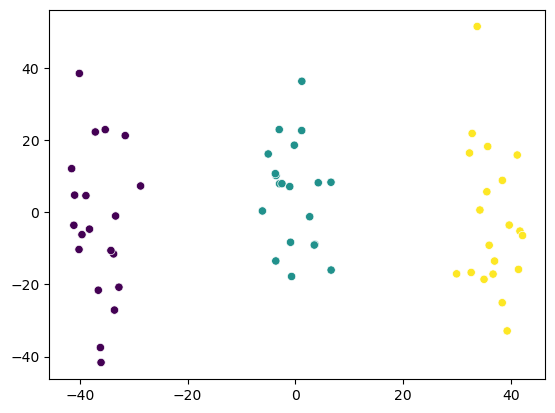

In [7]:
sns.scatterplot(x=scores[:,0],y=scores[:,1],hue=true_class_label,palette='viridis', legend=False)
plt.show()

## (c)
```{admonition}
:class: note
Perform $K$-means clustering of the observations with $K = 3$. How well do the clusters that you obtained in $K$-means clustering compare to the true class labels?

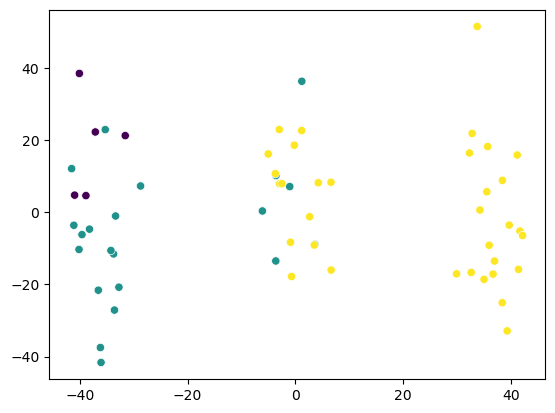

ARI:0.3762


col_0,0,1,2
row_0,,,
0,5,0,0
1,15,6,0
2,0,14,20


In [8]:
kmean3 = KMeans(random_state=1728,n_clusters=3)
kmean3.fit(obs)

pred3 = kmean3.predict(obs)
sns.scatterplot(x=scores[:,0],y=scores[:,1],hue=pred3,palette='viridis', legend=False)
plt.show()

ari3 = adjusted_rand_score(true_class_label, pred3)
print(f'ARI:{ari3:.4f}')

pd.crosstab(pred3,true_class_label)

## (d)
```{admonition}
:class: note
Perform $K$-means clustering with $K = 2$. Describe your results.

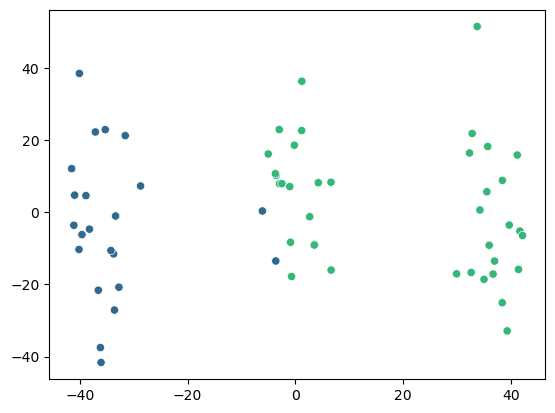

ARI:0.5169


col_0,0,1,2
row_0,,,
0,20,2,0
1,0,18,20


In [9]:
kmean2 = KMeans(random_state=1728,n_clusters=2)
kmean2.fit(obs)

pred2 = kmean2.predict(obs)
sns.scatterplot(x=scores[:,0],y=scores[:,1],hue=pred2,palette='viridis', legend=False)
plt.show()

ari2 = adjusted_rand_score(true_class_label, pred2)
print(f'ARI:{ari2:.4f}')

pd.crosstab(pred2,true_class_label)

## (e)
```{admonition}
:class: note
Now perform $K$-means clustering with $K = 4$, and describe your results.

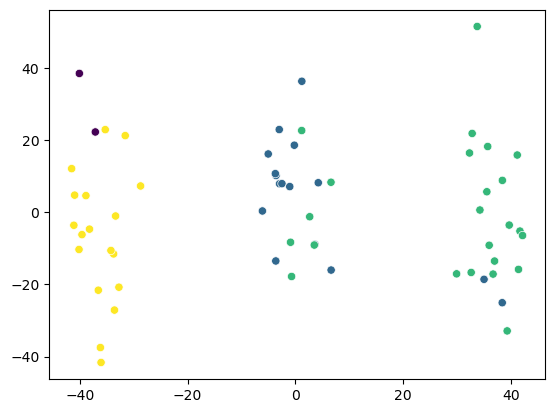

ARI:0.6187


col_0,0,1,2
row_0,,,
0,2,0,0
1,0,14,2
2,0,6,18
3,18,0,0


In [10]:
kmean4 = KMeans(random_state=1728,n_clusters=4)
kmean4.fit(obs)

pred4 = kmean4.predict(obs)
sns.scatterplot(x=scores[:,0],y=scores[:,1],hue=pred4,palette='viridis', legend=False)
plt.show()

ari4 = adjusted_rand_score(true_class_label, pred4)
print(f'ARI:{ari4:.4f}')

pd.crosstab(pred4,true_class_label)

## (f)
```{admonition}
:class: note
Now perform $K$-means clustering with $K = 3$ on the first two principal component score vectors, rather than on the raw data.

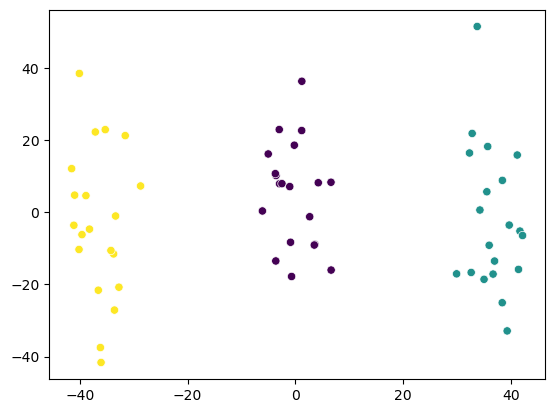

ARI:1.0000


col_0,0,1,2
row_0,,,
0,0,20,0
1,0,0,20
2,20,0,0


In [11]:
kmean3_pc = KMeans(random_state=1728,n_clusters=3)
kmean3_pc.fit(scores[:,0:2])

pred3_pc = kmean3_pc.predict(scores[:,0:2])
sns.scatterplot(x=scores[:,0],y=scores[:,1],hue=pred3_pc,palette='viridis', legend=False)
plt.show()

ari3_pc = adjusted_rand_score(true_class_label, pred3_pc)
print(f'ARI:{ari3_pc:.4f}')

pd.crosstab(pred3_pc,true_class_label)

## (g)
```{admonition}
:class: note
Using the `StandardScaler()` estimator, perform $K$-means clustering with $K = 3$ on the data after scaling each variable to have standard deviation one.

In [12]:
scaler = StandardScaler()
obs_scaled = scaler.fit_transform(obs)

pca2 = PCA()
scores_scaled = pca2.fit_transform(obs_scaled)

pd.DataFrame(obs_scaled).std(ddof=0)

0     1.0
1     1.0
2     1.0
3     1.0
4     1.0
5     1.0
6     1.0
7     1.0
8     1.0
9     1.0
10    1.0
11    1.0
12    1.0
13    1.0
14    1.0
15    1.0
16    1.0
17    1.0
18    1.0
19    1.0
20    1.0
21    1.0
22    1.0
23    1.0
24    1.0
25    1.0
26    1.0
27    1.0
28    1.0
29    1.0
30    1.0
31    1.0
32    1.0
33    1.0
34    1.0
35    1.0
36    1.0
37    1.0
38    1.0
39    1.0
40    1.0
41    1.0
42    1.0
43    1.0
44    1.0
45    1.0
46    1.0
47    1.0
48    1.0
49    1.0
dtype: float64

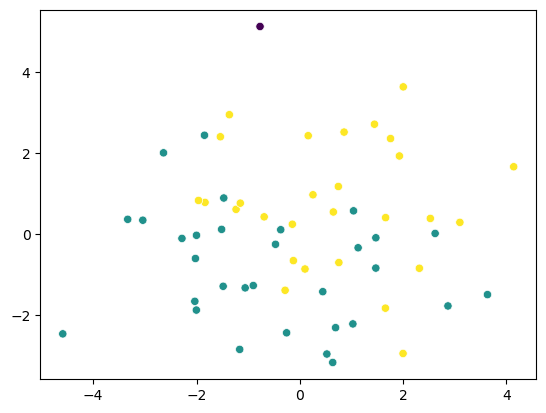

ARI:0.0817


col_0,0,1,2
row_0,,,
0,1,0,0
1,15,6,10
2,4,14,10


In [13]:
kmean3_sc = KMeans(random_state=1728,n_clusters=3)
kmean3_sc.fit(obs_scaled)

pred3_sc = kmean3_sc.predict(obs_scaled)
sns.scatterplot(x=scores_scaled[:,0],y=scores_scaled[:,1],hue=pred3_sc,palette='viridis', legend=False)
plt.show()

ari3_sc = adjusted_rand_score(true_class_label, pred3_sc)
print(f'ARI:{ari3_sc:.4f}')

pd.crosstab(pred3_sc,true_class_label)

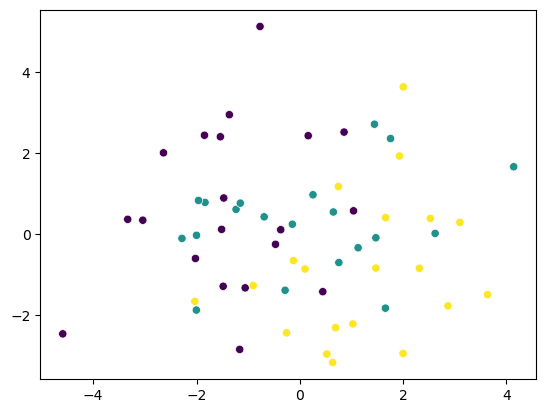

In [14]:
sns.scatterplot(x=scores_scaled[:,0],y=scores_scaled[:,1],hue=true_class_label,palette='viridis', legend=False)
plt.show()